# $\mathrm{K}_{\mathrm{V}}2.1$ | WT and mutant experimental-reference RMSD

This notebook asks two related questions. First, does targeted masking broaden the
structural ensemble relative to vanilla AlphaFold2? Second, do L403A or F412L models
move toward the experimentally resolved L403A geometry (8SDA) rather than the WT
geometry (8SD3)?

Only models in the established **allOK3** convergence subset are retained. The
corrected v2 RMSD table is then used to remove rows carrying a chain-mapping warning.
This second step is essential because an otherwise cyclically plausible chain
assignment can generate the nonphysical RMSD tail seen in the earlier analysis.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'shared').is_dir())
sys.path.insert(0,str(repo_root))
from shared.rmsd_analysis import humanize_measurement,apply_kv21_rmsd_qc
from shared.plotting import ensemble_protocol_palette

SOURCE=repo_root/'kv21/dataRMSD/Kv21_all_models_vs_8SD3_8SDA_RMSD_v2.csv'
MANIFEST=repo_root/'kv21/dataRMSF/qc/kv21_all_ok3_selection_manifest.csv'
FIG=repo_root/'kv21/dataRMSD/analysis/comparison/figures'
TABLE=repo_root/'kv21/dataRMSD/analysis/comparison'
FIG.mkdir(parents=True,exist_ok=True); TABLE.mkdir(parents=True,exist_ok=True)

REGIONS={
 'whole_matched_tetramer__ca__core_aligned_rmsd_A':'Whole matched tetramer',
 's6_bundle_working__ca__core_aligned_rmsd_A':'Four-chain S6 bundle',
 'distal_s6_working__ca__core_aligned_rmsd_A':'Distal S6',
 'hydrophobic_nexus__ca__core_aligned_rmsd_A':'Hydrophobic coupling nexus',
 'l403_region__ca__core_aligned_rmsd_A':'L403 region',
 'f412_region__ca__core_aligned_rmsd_A':'F412 region',
}
META=['dataset','sequence_condition','protocol','pdb_file','reference_id',
      'analysis_status','analysis_error','selected_core_postfit_rmsd_A',
      'all24_improvement_over_d4_A','d4_mapping_rmsd_gap_A']
df=pd.read_csv(SOURCE,usecols=META+list(REGIONS),low_memory=False)
manifest=pd.read_csv(MANIFEST,usecols=['pdb_basename','all_ok_3'])
selected=set(manifest.loc[manifest.all_ok_3.fillna(False),'pdb_basename'].astype(str))
raw_n=len(df)
df=df[df.pdb_file.astype(str).map(lambda x:Path(x).name).isin(selected)].copy()
allok3_n=len(df)
warning=df[~df.analysis_status.eq('ok')].copy()
df=df[df.analysis_status.eq('ok')].copy()
df=apply_kv21_rmsd_qc(df,repo_root)
df['Sequence']=df.sequence_condition.str.upper()
df['Protocol']=df.protocol.map({'vanilla':'Vanilla','masked':'Masked'})
SEQUENCE_ORDER=['WT','L403A','F412L']
PROTOCOL_ORDER=['Vanilla','Masked']
SEQUENCE_PALETTES={
    sequence:ensemble_protocol_palette('kv21',sequence.lower())
    for sequence in SEQUENCE_ORDER
}
print(f'{raw_n:,} raw reference rows → {allok3_n:,} allOK3 rows → {len(df):,} mapping-QC-passing rows')
print(f'{df.pdb_file.nunique():,} unique models retained')

Kv2.1 structural RMSD QC: 49,314 rows → 48,876 after tetramer/interface QC → 48,538 after excluding 21 separated alignment-failure trajectories (stable-core cutoff 4 Å)
71,988 raw reference rows → 51,804 allOK3 rows → 48,538 mapping-QC-passing rows
24,269 unique models retained


## QC and retained models

The bar height is the number of unique structural snapshots available for each
sequence/protocol combination after both filters. The rejected rows are retained
as a provenance table and are not mixed into any biological comparison.

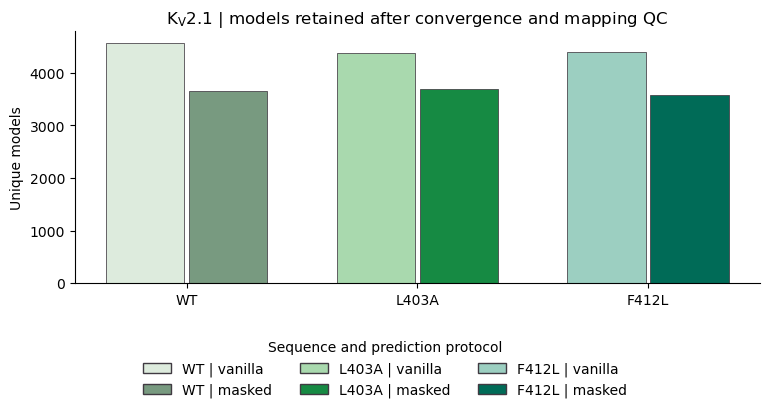

,Sequence,Protocol,models
0,F412L,Masked,3578
1,F412L,Vanilla,4407
2,L403A,Masked,3693
3,L403A,Vanilla,4371
4,WT,Masked,3658
5,WT,Vanilla,4562


In [2]:
counts=df.groupby(['Sequence','Protocol']).pdb_file.nunique().rename('models').reset_index()
counts.to_csv(TABLE/'model_counts_allOK3_mappingQC.csv',index=False)
warning[['sequence_condition','protocol','pdb_file','reference_id','analysis_error',
         'selected_core_postfit_rmsd_A','all24_improvement_over_d4_A']].to_csv(
    TABLE/'excluded_mapping_warning_rows.csv',index=False)
fig,ax=plt.subplots(figsize=(7.8,4.2))
for sequence_index,sequence in enumerate(SEQUENCE_ORDER):
    for protocol in PROTOCOL_ORDER:
        row=counts[(counts.Sequence==sequence)&(counts.Protocol==protocol)]
        if row.empty: continue
        offset=-.18 if protocol=='Vanilla' else .18
        ax.bar(sequence_index+offset,row.models.iloc[0],width=.34,
               color=SEQUENCE_PALETTES[sequence][protocol],
               edgecolor='#403A42',linewidth=.55)
ax.set_xticks(range(len(SEQUENCE_ORDER)),SEQUENCE_ORDER)
ax.set(xlabel='',ylabel='Unique models',
       title=r'$\mathrm{K}_{\mathrm{V}}2.1$ | models retained after convergence and mapping QC')
handles=[
    plt.Rectangle((0,0),1,1,facecolor=SEQUENCE_PALETTES[sequence][protocol],
                  edgecolor='#403A42',label=f'{sequence} | {protocol.lower()}')
    for sequence in SEQUENCE_ORDER for protocol in PROTOCOL_ORDER
]
fig.legend(handles=handles,title='Sequence and prediction protocol',
           loc='lower center',bbox_to_anchor=(.5,.01),ncol=3,frameon=False)
sns.despine(); fig.tight_layout(rect=(0,.22,1,1))
fig.savefig(FIG/'01_retained_models.png',dpi=400,bbox_inches='tight'); plt.show()
display(counts)

## Experimental-reference preference

For every model and region, the paired score is

$$
\Delta_{\mathrm{8SDA-8SD3}} =
\mathrm{RMSD}_{\mathrm{8SDA}}-\mathrm{RMSD}_{\mathrm{8SD3}}.
$$

Negative values indicate greater resemblance to the experimental L403A structure
8SDA; positive values indicate greater resemblance to WT 8SD3. This paired score is
more informative than comparing two independent RMSD distributions because the same
model is evaluated against both references.

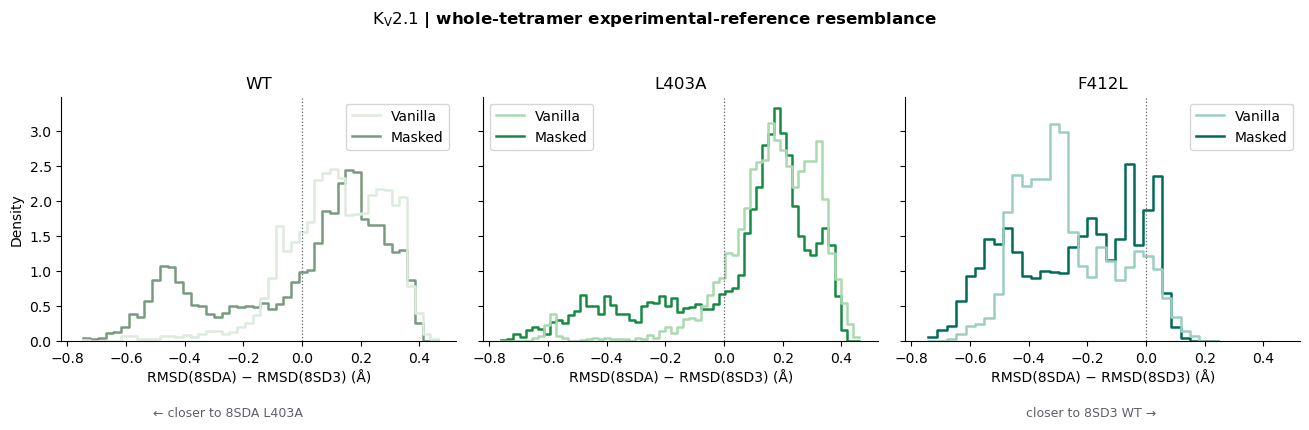

In [3]:
paired_tables=[]
for measurement,label in REGIONS.items():
    identity=['dataset','sequence_condition','Sequence','protocol','Protocol','pdb_file']
    p=df.pivot_table(index=identity,columns='reference_id',values=measurement,aggfunc='first').dropna().reset_index()
    p['delta_8SDA_minus_8SD3_A']=p['8SDA']-p['8SD3']
    p['Region']=label; p['measurement']=measurement
    paired_tables.append(p)
paired=pd.concat(paired_tables,ignore_index=True)
paired.to_csv(TABLE/'paired_reference_preference_by_region.csv',index=False)

focus=paired[paired.Region.eq('Whole matched tetramer')]
fig,axes=plt.subplots(1,3,figsize=(13.2,4.2),sharex=True,sharey=True)
for ax,sequence in zip(axes,SEQUENCE_ORDER):
    part=focus[focus.Sequence.eq(sequence)]
    sns.histplot(data=part,x='delta_8SDA_minus_8SD3_A',hue='Protocol',
                 hue_order=PROTOCOL_ORDER,palette=SEQUENCE_PALETTES[sequence],element='step',fill=False,
                 stat='density',common_norm=False,linewidth=1.8,ax=ax)
    ax.axvline(0,color='#625D68',lw=.9,ls=':')
    ax.set(title=sequence,xlabel='RMSD(8SDA) − RMSD(8SD3) (Å)',ylabel='Density')
    if ax.legend_: ax.legend_.set_title('')
    sns.despine(ax=ax)
fig.suptitle(r'$\mathrm{K}_{\mathrm{V}}2.1$ | whole-tetramer experimental-reference resemblance',
             fontweight='semibold')
fig.text(.12,.01,'← closer to 8SDA L403A',ha='left',fontsize=9,color='#625D68')
fig.text(.88,.01,'closer to 8SD3 WT →',ha='right',fontsize=9,color='#625D68')
fig.tight_layout(rect=(0,.05,1,.94))
fig.savefig(FIG/'02_whole_tetramer_reference_preference.png',dpi=400,bbox_inches='tight')
plt.show()

## Where does the reference preference occur?

The split violins retain the full distribution. They distinguish a global
whole-tetramer resemblance from localized changes in S6 and the hydrophobic
coupling nexus. A mutant can therefore resemble 8SDA globally without reproducing
every local experimental displacement.

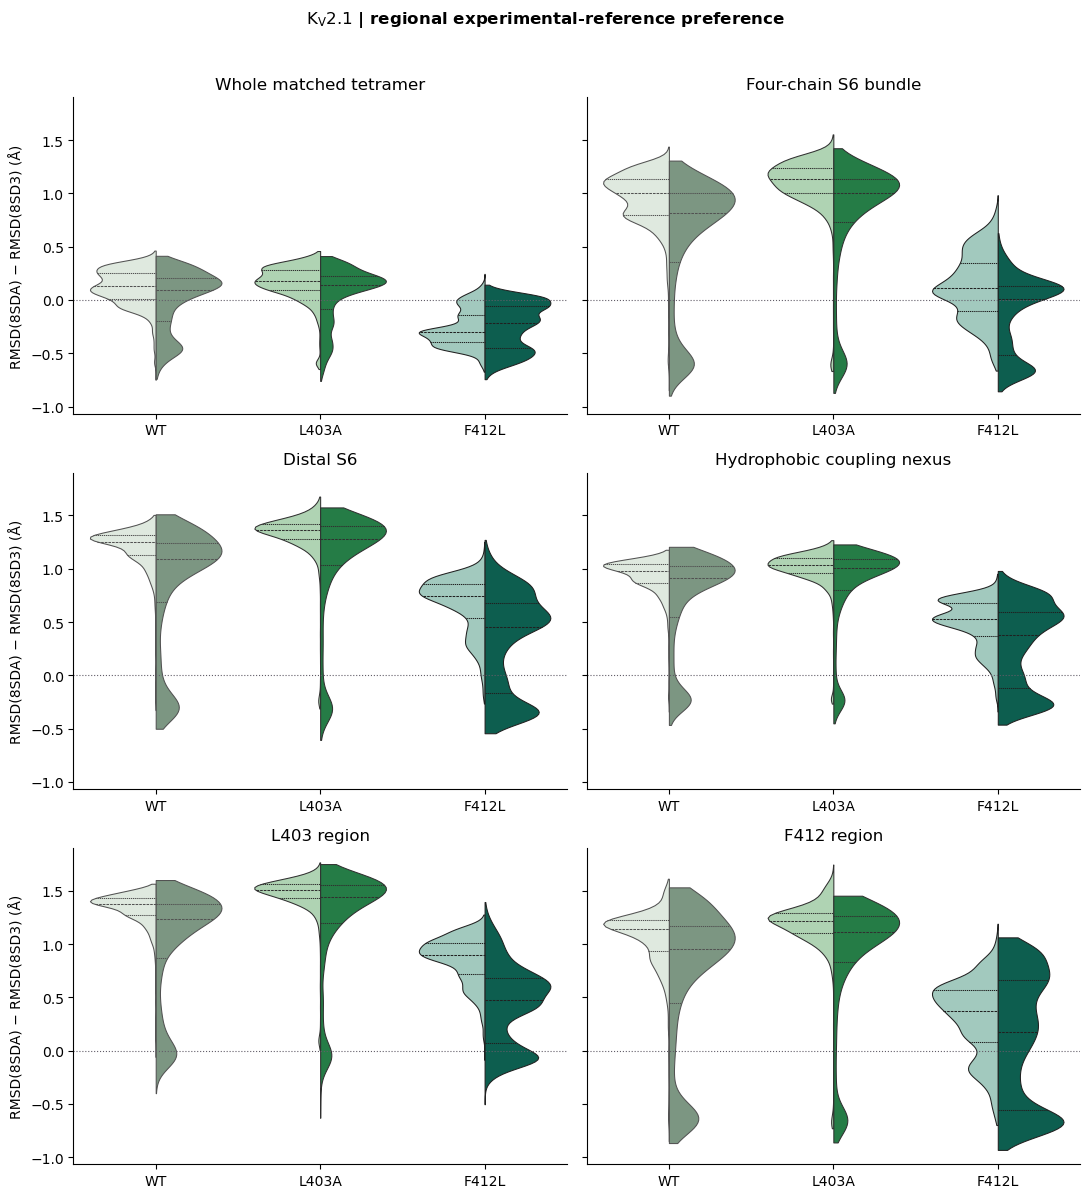

In [4]:
regions=list(REGIONS.values())
fig,axes=plt.subplots(3,2,figsize=(11,12),sharey=True)
for ax,region in zip(axes.flat,regions):
    region_part=paired[paired.Region.eq(region)]
    for sequence in SEQUENCE_ORDER:
        sns.violinplot(data=region_part[region_part.Sequence.eq(sequence)],
                       x='Sequence',y='delta_8SDA_minus_8SD3_A',hue='Protocol',
                       order=SEQUENCE_ORDER,hue_order=PROTOCOL_ORDER,
                       palette=SEQUENCE_PALETTES[sequence],split=True,inner='quart',
                       cut=0,density_norm='width',linewidth=.75,ax=ax,legend=False)
    ax.set(title=region,xlabel='',ylabel='RMSD(8SDA) − RMSD(8SD3) (Å)')
    ax.axhline(0,color='#625D68',lw=.8,ls=':')
    sns.despine(ax=ax)
fig.suptitle(r'$\mathrm{K}_{\mathrm{V}}2.1$ | regional experimental-reference preference',
             fontweight='semibold',y=.995)
fig.tight_layout(rect=(0,0,1,.98))
fig.savefig(FIG/'03_regional_reference_preference.png',dpi=400,bbox_inches='tight')
plt.show()

## Descriptive summary

Fractions are calculated per structural snapshot. Because recycle snapshots from
one trajectory are correlated, these values describe ensemble occupancy and are not
treated as independent-sample probabilities.

In [5]:
summary=(paired.groupby(['Region','Sequence','Protocol'])
 .agg(n=('pdb_file','size'),
      median_delta_A=('delta_8SDA_minus_8SD3_A','median'),
      p05_delta_A=('delta_8SDA_minus_8SD3_A',lambda x:x.quantile(.05)),
      p95_delta_A=('delta_8SDA_minus_8SD3_A',lambda x:x.quantile(.95)),
      fraction_closer_to_8SDA=('delta_8SDA_minus_8SD3_A',lambda x:(x<0).mean()))
 .reset_index())
summary.to_csv(TABLE/'reference_preference_summary.csv',index=False)
display(summary.sort_values(['Region','Sequence','Protocol']))

,Region,Sequence,Protocol,n,median_delta_A,p05_delta_A,p95_delta_A,fraction_closer_to_8SDA
0,Distal S6,F412L,Masked,3578,0.457466,-0.385083,0.924811,0.315819
1,Distal S6,F412L,Vanilla,4407,0.742108,0.174925,0.968914,0.019287
2,Distal S6,L403A,Masked,3693,1.274999,-0.318290,1.493271,0.110209
3,Distal S6,L403A,Vanilla,4371,1.363962,1.075036,1.518462,0.016930
4,Distal S6,WT,Masked,3658,1.090140,-0.333392,1.411445,0.173866
5,Distal S6,WT,Vanilla,4562,1.254788,0.859298,1.392233,0.006795
6,F412 region,F412L,Masked,3578,0.175228,-0.716209,0.950104,0.416713
7,F412 region,F412L,Vanilla,4407,0.376141,-0.319798,0.798748,0.215793
8,F412 region,L403A,Masked,3693,1.116002,-0.656645,1.396892,0.129976
9,F412 region,L403A,Vanilla,4371,1.218253,0.865392,1.479521,0.020133
